# Force-directed layout for Omi32 combinatorial library from Tharp et al, 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import igraph as ig
import random
from matplotlib.lines import Line2D

mpl.rcParams['figure.dpi'] = 300
L = 13
sequences_int = range(2**L)

def reachable(s, L):
    return [(s | 2**ii) for ii in range(L) if (s | 2**ii) > s]
mutation_names = ['1','2','3','4','5','6','7','8','9','10','11','12','13']

In [2]:
# Map phenotype names to file naming convention
phenotype_files = {
    'BA1': '../epistasis_inference/linear_interaction_models/ba1/reference-based/predicted_phenotypes/ba1_raw_3order_full_biochem_predictions.csv',
    'BA4': '../epistasis_inference/linear_interaction_models/ba4/reference-based/predicted_phenotypes/ba4_raw_3order_full_biochem_predictions.csv',
    'WUHAN': '../epistasis_inference/linear_interaction_models/wuhan/reference-based/predicted_phenotypes/wuhan_raw_2order_full_biochem_predictions.csv',  
    'PSR': '../epistasis_inference/linear_interaction_models/psr/reference-based/predicted_phenotypes/psr_raw_2order_full_biochem_predictions.csv',       
    'Expression': '../epistasis_inference/linear_interaction_models/expression/reference-based/predicted_phenotypes/expression_raw_2order_full_biochem_predictions.csv'  
}

# IMPORTANT: Load predictions BEFORE reindexing to full genotype space
# This ensures we get predictions for all 8192 genotypes

# Load BA1 predictions (used for generating the force-directed layout)
pred_ba1 = pd.read_csv(f"{phenotype_files['BA1']}", dtype={"geno":"str"}).set_index("geno")

# Load other phenotype predictions
pred_ba4 = pd.read_csv(f"{phenotype_files['BA4']}", dtype={"geno":"str"}).set_index("geno")
pred_wuhan = pd.read_csv(f"{phenotype_files['WUHAN']}", dtype={"geno":"str"}).set_index("geno")
pred_psr = pd.read_csv(f"{phenotype_files['PSR']}", dtype={"geno":"str"}).set_index("geno")
pred_expr = pd.read_csv(f"{phenotype_files['Expression']}", dtype={"geno":"str"}).set_index("geno")

print("Predicted phenotype data loaded successfully!")
print(f"  BA1: {len(pred_ba1)} predictions")
print(f"  BA4: {len(pred_ba4)} predictions")
print(f"  WUHAN: {len(pred_wuhan)} predictions")
print(f"  PSR: {len(pred_psr)} predictions")
print(f"  Expression: {len(pred_expr)} predictions")

df = pred_ba1.reset_index()[["geno"]].copy()  # Start with genotypes from BA1 predictions
df["variant_int"] = df.geno.apply(lambda x: int(x, 2) if pd.notna(x) else np.nan)

df = df.set_index("variant_int").reindex(range(0, 2**L)).reset_index()
df["geno"] = df.variant_int.apply(lambda x: f"{x:0{L}b}")

# NOW map predictions after we have all genotypes in df
df['log10Kd'] = df.geno.map(pred_ba1.predicted_phenotype)
df['err_log10Kd'] = df.geno.map(pred_ba1.prediction_se)
df['log10Kd_BA4'] = df.geno.map(pred_ba4.predicted_phenotype)
df['err_log10Kd_BA4'] = df.geno.map(pred_ba4.prediction_se)
df['log10Kd_WUHAN'] = df.geno.map(pred_wuhan.predicted_phenotype)
df['err_log10Kd_WUHAN'] = df.geno.map(pred_wuhan.prediction_se)
df['log10Kd_PSR'] = df.geno.map(pred_psr.predicted_phenotype)
df['err_log10Kd_PSR'] = df.geno.map(pred_psr.prediction_se)
df['mean_expr'] = df.geno.map(pred_expr.predicted_phenotype)
df['sem_expr'] = df.geno.map(pred_expr.prediction_se)

sequences_int = range(0,2**L)
for ii in range(L):
    df[f"mutation_{ii+1}"] = df.geno.str[ii] == '1'
    
df["expression_norm"] = df['mean_expr']/df['mean_expr'].mean()

print(f"\nFinal dataframe has predictions for all {len(df)} genotypes")
print(f"Missing predictions: {df['log10Kd'].isna().sum()} (should be 0)")


Predicted phenotype data loaded successfully!
  BA1: 8192 predictions
  BA4: 8192 predictions
  WUHAN: 8192 predictions
  PSR: 8192 predictions
  Expression: 8192 predictions

Final dataframe has predictions for all 8192 genotypes
Missing predictions: 0 (should be 0)


In [3]:
# Check the loaded data
print("\nData shape:", df.shape)
print("\nFirst few rows:")
print(df[["geno", "log10Kd", "err_log10Kd", "log10Kd_BA4", "log10Kd_WUHAN", "log10Kd_PSR", "mean_expr"]].head(10))
print("\nMissing values:")
print(df[["log10Kd", "log10Kd_BA4", "log10Kd_WUHAN", "log10Kd_PSR", "mean_expr"]].isna().sum())


Data shape: (8192, 26)

First few rows:
            geno   log10Kd  err_log10Kd  log10Kd_BA4  log10Kd_WUHAN  \
0  0000000000000  7.398105     0.069789     6.874339       6.709208   
1  0000000000001  7.484630     0.067803     6.835322       6.734938   
2  0000000000010  8.565534     0.068491     7.073525       6.908735   
3  0000000000011  8.698161     0.067024     7.039201       6.898220   
4  0000000000100  7.389404     0.068265     7.173606       7.620991   
5  0000000000101  7.435877     0.067514     7.084787       7.647089   
6  0000000000110  8.426068     0.066318     7.515883       7.722241   
7  0000000000111  8.543247     0.066661     7.431001       7.712094   
8  0000000001000  7.390630     0.067445     6.835979       6.483083   
9  0000000001001  7.502591     0.068074     6.866480       6.558132   

   log10Kd_PSR  mean_expr  
0     2.122274   4.227666  
1     2.103620   4.226895  
2     2.151228   4.194454  
3     2.143346   4.187310  
4     2.083507   4.246568  
5     2.1

## Build force-directed graph

**Note**: The graph construction now uses predicted phenotype data for edge weights. You can choose which phenotype to use for coloring the graph.

In [4]:
# read data into graph


fitnesses = {}
fitnesses["BA1"] = (df.set_index("variant_int")["log10Kd"]).to_dict()
for ab in ['BA4', 'WUHAN', 'PSR']:
    fitnesses[ab] = (df.set_index("variant_int")["log10Kd"]).to_dict()
    
g = ig.Graph()
vertices = [s for s in sequences_int if ~np.isnan(fitnesses["BA1"][s])]
g.add_vertices([str(s) for s in vertices])
g.add_edges([(str(s),str(t)) for s in vertices for t in reachable(s, L) if t in vertices])


#### weight choices ####
# high weight means very close nodes on the graph.
weight_strength = 30000
min_difference = 1e-5
g.es["weight"] = [weight_strength/(min_difference 
                                   + np.abs(fitnesses["BA1"][t] - fitnesses["BA1"][s]) ) # weight
                            for s in vertices
                  for t in reachable(s, L) if t in vertices]
########################

g.vs["endpoints"] = [(s == 0 or s == len(sequences_int)-1) for s in sequences_int]

In [5]:
# draw the layout

# generate seed
random.seed(42) 
seed = np.empty((len(vertices),2))
for i in range(len(vertices)):
    xcoord = random.uniform(-100,100)
    ycoord = random.uniform(-100,100)
    seed[i,:] = [xcoord,ycoord]
    
# create layout
layout = g.layout_drl(weights='weight',seed=seed)

# update df
coord =  np.array(layout.coords)
#print(coord)
xcoord = {vertices[i]:-1.0*coord[i, 1] for i in range(len(vertices))}
ycoord = {vertices[i]:coord[i, 0] for i in range(len(vertices))}
df["fdl_x"] = df.variant_int.map(xcoord)
df["fdl_y"] = df.variant_int.map(ycoord)

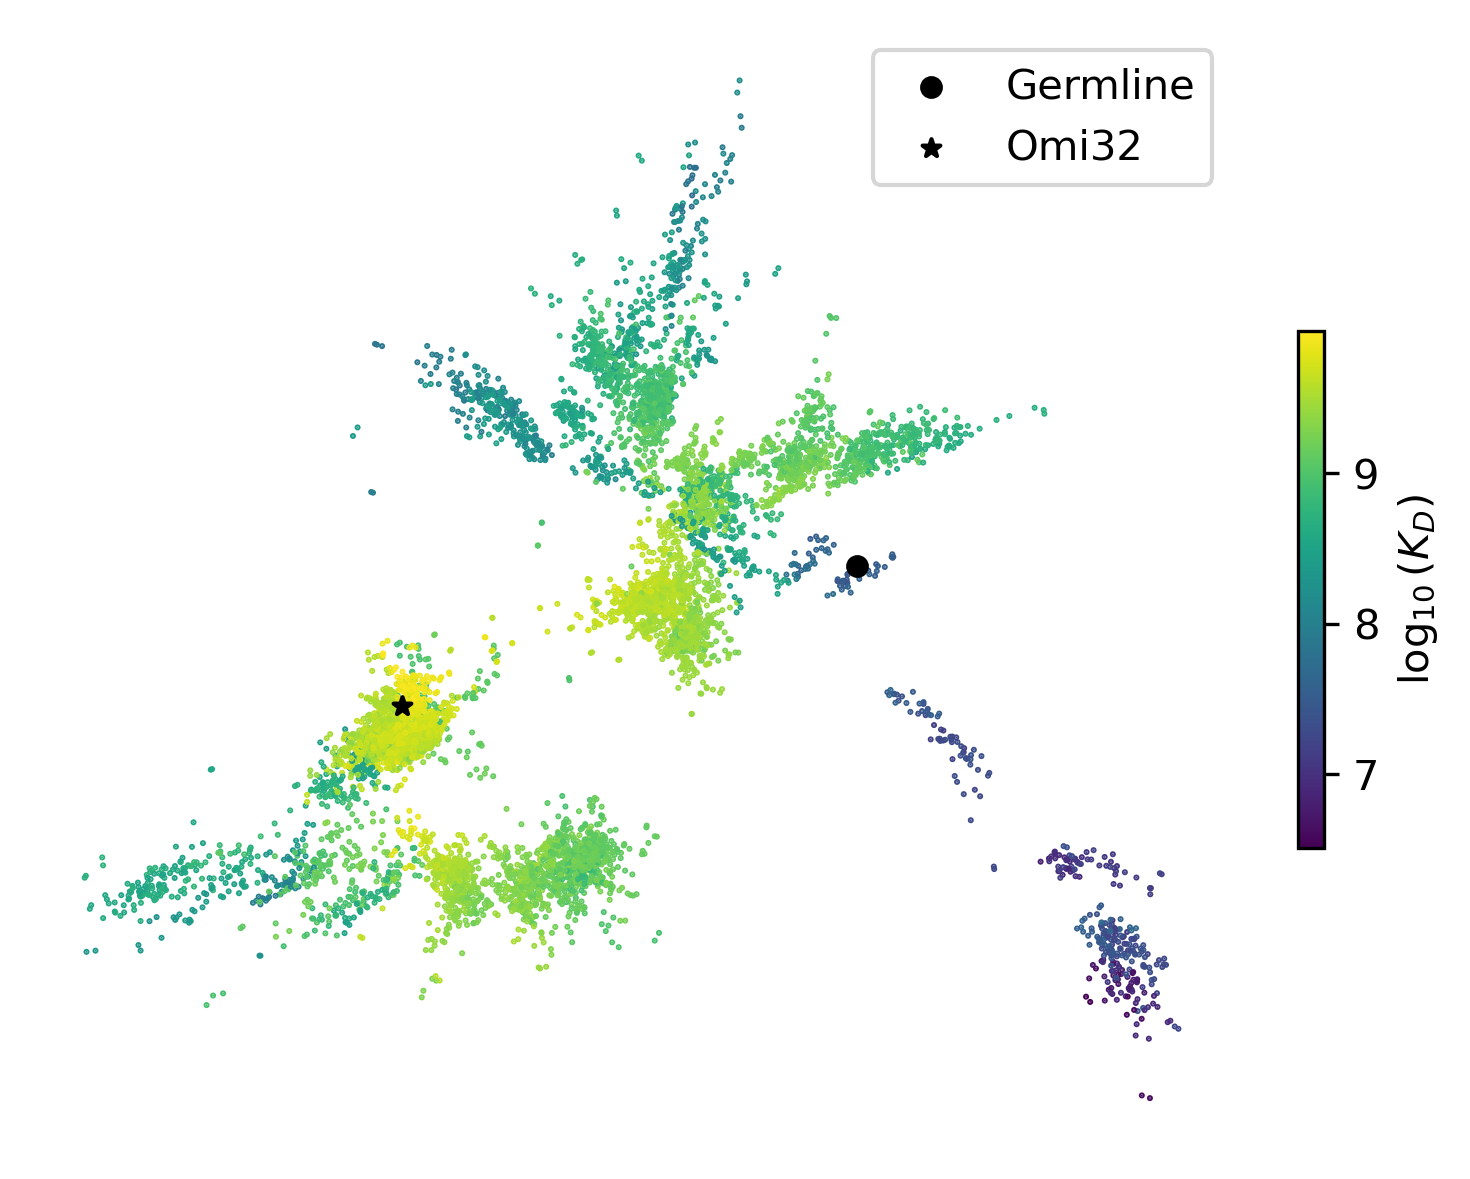

In [6]:
fig, ax = plt.subplots(figsize=(5,5))
sc = ax.scatter(x=df.fdl_x, y=df.fdl_y,
           s=0.2, c=df.log10Kd, alpha=1)
plt.colorbar(sc,fraction=0.02,label=r"$\log_{10}(K_D)$")

ax.scatter(x=df[df.geno == "0"*L].fdl_x, y=df[df.geno == "0"*L].fdl_y,
           s=20, c='black', alpha=1, marker="o", label='Germline', zorder=5)
ax.scatter(x=df[df.geno == "1"*L].fdl_x, y=df[df.geno == "1"*L].fdl_y,
           s=20, c="black", alpha=1, marker="*", label='Omi32', zorder=5)
ax.legend(loc="best", frameon=True)
ax.set_aspect('equal')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [7]:
## Generate files for data browser

In [8]:
## Prepare the csv for the data browser
df["variant"] = df.geno
df["BA1_log10Kd"] = -df.log10Kd
df["BA1_stelog10Kd"] = df.err_log10Kd
# not actually a Kd but the browser is dumb
df["Expression_log10Kd"] = df.expression_norm
df["Expression_stelog10Kd"] = df["sem_expr"]


for ab in ['BA4', 'WUHAN', 'PSR']:
    df[f"{ab}_log10Kd"] = -df[f"log10Kd_{ab}"]
    df[f"{ab}_stelog10Kd"] = df[f"err_log10Kd_{ab}"]

solutes = ['BA1','BA4', 'WUHAN', 'PSR']
for ab in solutes:
    for ii in range(L):
        Kds = df.set_index("geno")[f"{ab}_log10Kd"].to_dict()
        df[f"{ab}_{ii}_deltaKd"] = df.geno.apply(lambda x: (x,x[:ii]+'1'+x[ii+1:]) if x[ii] == '0' else "null")
        df[f"{ab}_{ii}_deltaKd"] = df[f"{ab}_{ii}_deltaKd"].apply(lambda x: Kds[x[1]] - Kds[x[0]]
                                                                  if x != "null" else "null")

df[["variant"] +
    [f"{ab}_log10Kd" for ab in solutes] + [f"{ab}_stelog10Kd" for ab in solutes]
    + ["Expression_log10Kd", "Expression_stelog10Kd",
    "fdl_x", "fdl_y"] + 
   [f"{ab}_{ii}_deltaKd" for ii in range(L) for ab in solutes]
  ].to_csv("data/Omi32.csv")


## Prepare the mean bin pyarrow for the data browser
for ab in solutes:
    dfmb = df.copy()
    repscon = set([(a.split("_")[-2], int(a.split("_")[1][7:]))
                for a in dfmb.keys() 
                if a.startswith("mean_log10PE") and a.endswith(ab)])
    cols = ["variant", f"{ab}_log10Kd"]
    for aa, ii in repscon:
        dfmb[f"c{ii}_{aa}"] = dfmb[f"mean_log10PE{ii}_{aa}_{ab}"]
        dfmb[f"e{ii}_{aa}"] = dfmb[f"std_log10PE{ii}_{aa}_{ab}"]
        cols += [f"c{ii}_{aa}", f"e{ii}_{aa}"]
    dfmb.dropna(subset=[f"{ab}_log10Kd"]).reset_index()[cols].to_feather(
        f"data/{ab}.arrow", compression="uncompressed")